# Life Expectancy Regression

Predict country-level **life expectancy** from health, demographic, and socio-economic indicators using classical regression models.

| Item | Detail |
|------|--------|
| Task | Regression (`Life expectancy`) |
| Input | WHO-style country/year features (immunization, GDP, schooling, mortality, …) |
| Models | Custom Random Forest, Linear Regression, Decision Tree |
| Metrics | RMSE (primary), MAE |
| Split | 60 / 20 / 20 train / validation / test |


## Setup


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

REPO_ROOT = Path("../../..").resolve()
if not (REPO_ROOT / "common" / "portfolio_style.py").exists():
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "common" / "portfolio_style.py").exists():
            REPO_ROOT = candidate
            break
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from common.portfolio_style import PALETTE, apply_mpl_style

apply_mpl_style()

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)


def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)


Project root: /workspace/projects/life-expectancy-regression
Data directory: /workspace/projects/life-expectancy-regression/data/raw


## Data loading and split

We use a **60 / 20 / 20** train / validation / test split. Validation guides model selection; the test set is used once at the end to estimate generalization.


In [2]:
raw = pd.read_csv(DATA_DIR / "data.csv")
y = raw["Life expectancy"]
X = raw.drop(columns=["Life expectancy"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=SEED
)

print(f"Train: {X_train.shape[0]} | Validation: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print(f"Features ({X_train.shape[1]}): {list(X_train.columns)}")
print(f"Life expectancy — mean {y_train.mean():.1f}, std {y_train.std():.1f}")


Train: 1630 | Validation: 544 | Test: 544
Features (21): ['Country', 'Year', 'Status', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']
Life expectancy — mean 69.2, std 9.6


## Exploratory analysis

Life expectancy varies widely across countries. Several numeric fields have missing values, and `Status` / `Country` are categorical.


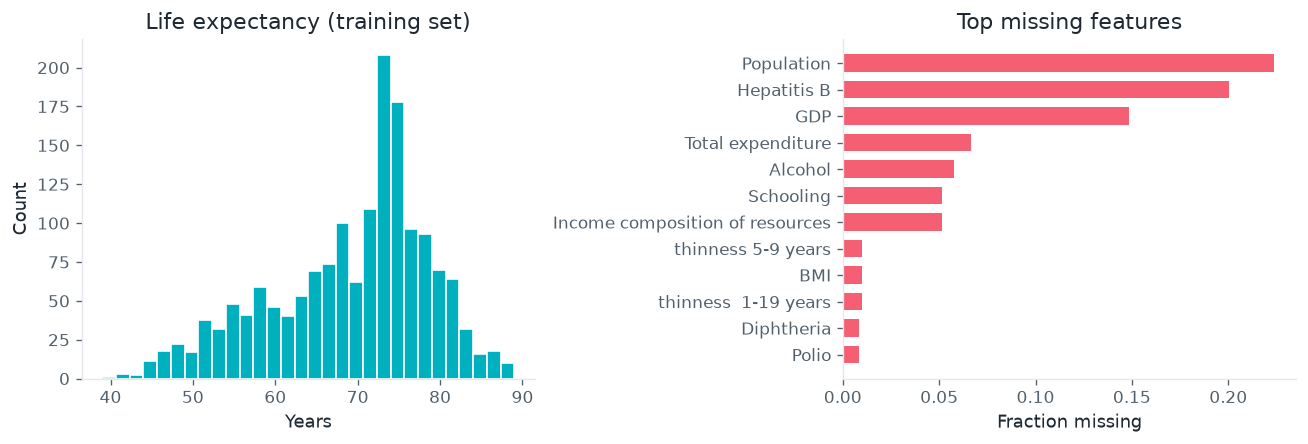

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country,1630,183,Iraq,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,1630.0,NaN,NaN,NaN,2007.090798,4.49736,2000.0,2003.0,2007.0,2011.0,2015.0
Status,1630,2,Developing,1364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Adult Mortality,1630.0,NaN,NaN,NaN,162.91227,121.880836,1.0,72.25,144.0,224.75,699.0
infant deaths,1630.0,NaN,NaN,NaN,29.666258,112.819272,0.0,0.0,3.0,21.0,1800.0
Alcohol,1536.0,NaN,NaN,NaN,4.670833,3.996543,0.01,1.02,3.965,7.6425,16.99
percentage expenditure,1630.0,NaN,NaN,NaN,735.055855,2005.856774,0.0,6.104678,70.299852,438.109002,19479.91161
Hepatitis B,1303.0,NaN,NaN,NaN,81.403684,24.877606,2.0,78.0,92.0,97.0,99.0
Measles,1630.0,NaN,NaN,NaN,2664.37362,13065.469043,0.0,0.0,17.0,372.0,212183.0
BMI,1614.0,NaN,NaN,NaN,37.818154,19.853478,1.4,18.9,43.1,55.8,77.1


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].hist(y_train.dropna(), bins=30, color=PALETTE["med_blue"], edgecolor="white")
axes[0].set_title("Life expectancy (training set)")
axes[0].set_xlabel("Years")
axes[0].set_ylabel("Count")

missing = X_train.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0].head(12)
axes[1].barh(missing.index, missing.values, color=PALETTE["med_pink"], height=0.65)
axes[1].set_xlabel("Fraction missing")
axes[1].set_title("Top missing features")
axes[1].invert_yaxis()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_eda_overview.png", bbox_inches="tight")
plt.show()

display(X_train.describe(include="all").T.head(10))


## Preprocessing

- Encode `Status` as a binary `Developed` indicator and drop the original column.
- Drop `Country` and `Year` (high-cardinality / time identifiers that are awkward for these models).
- Remove near-collinear pairs seen in the correlation matrix (`under-five deaths`, `thinness 5-9 years`, `percentage expenditure`).
- Fill remaining missing numeric values with a sentinel (`-1`).


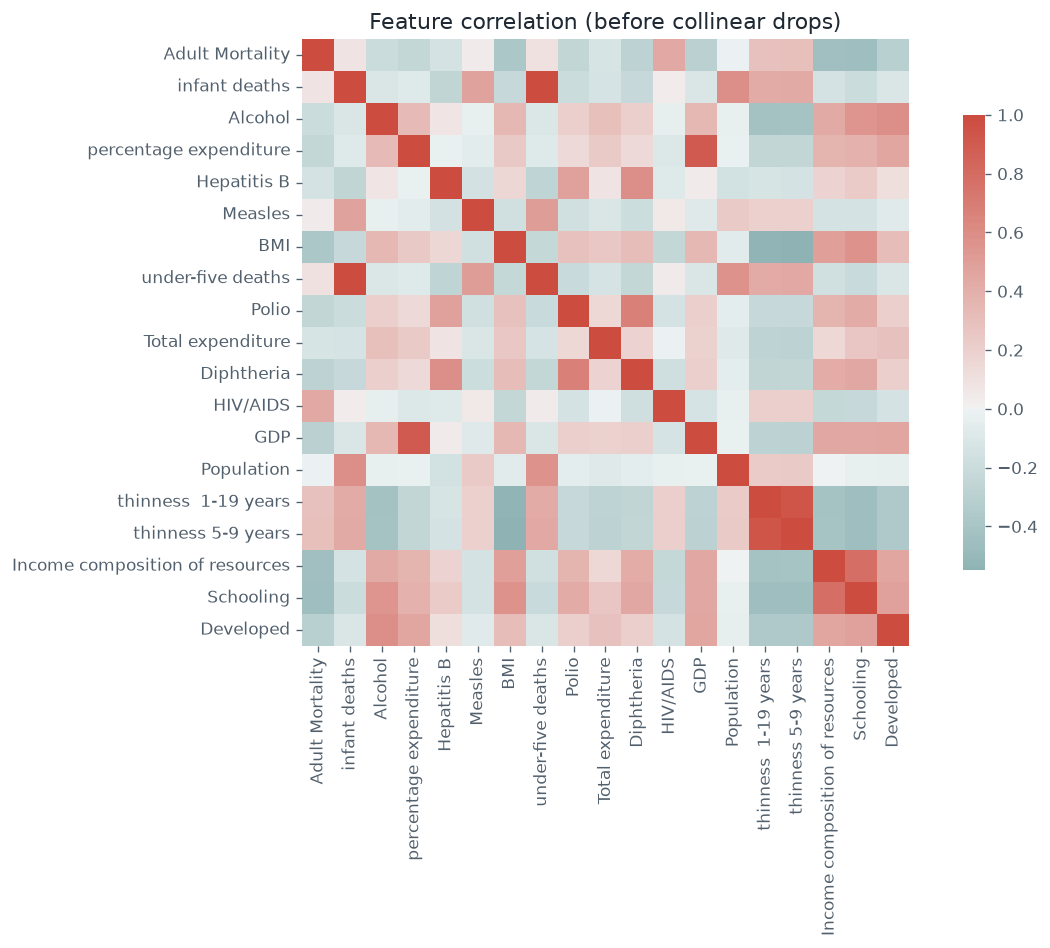

Features after preprocessing: ['Adult Mortality', 'infant deaths', 'Alcohol', 'Hepatitis B', 'Measles', 'BMI', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'Income composition of resources', 'Schooling', 'Developed']
Missing values left: 0


,Adult Mortality,infant deaths,Alcohol,Hepatitis B,Measles,BMI,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,Income composition of resources,Schooling,Developed
0,169.0,10,8.05,53.0,115,54.1,87.0,5.21,7.0,0.1,-1.000000,-1.0,1.8,0.672,10.4,0
1,182.0,0,4.94,99.0,0,32.4,99.0,2.64,99.0,0.1,976.956600,87298.0,5.8,0.739,13.2,0
2,32.0,5,2.98,-1.0,1,21.3,76.0,6.10,74.0,5.7,481.694976,1445958.0,8.7,0.394,8.8,0
3,277.0,239,0.01,75.0,72029,2.1,76.0,3.77,75.0,1.5,-1.000000,-1.0,1.0,-1.000,-1.0,0
4,94.0,0,10.26,-1.0,5,59.4,97.0,8.35,99.0,0.1,5341.314870,5313399.0,0.9,0.876,17.1,0


In [4]:
COLLINEAR_DROP = ["under-five deaths", "thinness 5-9 years", "percentage expenditure"]
ID_DROP = ["Country", "Year", "Status"]


def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["Developed"] = out["Status"].map({"Developed": 1, "Developing": 0}).astype(int)
    out = out.drop(columns=[c for c in ID_DROP + COLLINEAR_DROP if c in out.columns])
    out = out.fillna(-1)
    return out


# Correlation view before dropping collinear features (numeric only)
X_corr = X_train.copy()
X_corr["Developed"] = X_corr["Status"].map({"Developed": 1, "Developing": 0}).astype(int)
X_corr = X_corr.drop(columns=[c for c in ["Country", "Year", "Status"] if c in X_corr.columns])
X_corr = X_corr.select_dtypes(include=[np.number])

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    X_corr.corr(),
    annot=False,
    cmap=sns.diverging_palette(195, 15, s=70, l=50, as_cmap=True),
    center=0,
    square=True,
    cbar_kws={"shrink": 0.75},
    ax=ax,
)
ax.set_title("Feature correlation (before collinear drops)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_correlation_heatmap.png", bbox_inches="tight")
plt.show()

X_train_p = preprocess(X_train)
X_val_p = preprocess(X_val)
X_test_p = preprocess(X_test)

# Align indices for bootstrap sampling in the custom forest
X_train_p = X_train_p.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_val_p = X_val_p.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
X_test_p = X_test_p.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Features after preprocessing:", list(X_train_p.columns))
print("Missing values left:", int(X_train_p.isna().sum().sum()))
X_train_p.head()


## Custom Random Forest

A from-scratch bagging ensemble of regression trees: each tree is trained on a bootstrap sample of size `max_samples`, predictions are averaged. This captures non-linear structure without assuming a parametric form.


In [5]:
class CustomRandomForest:
    """Bagged ensemble of DecisionTreeRegressor models."""

    def __init__(self, n_estimators, max_samples, max_depth, random_state=None, **kwargs):
        self.n_estimators = n_estimators
        self.max_samples = max_samples
        self.max_depth = max_depth
        self.random_state = random_state
        self.kwargs = kwargs
        self.trees = []
        self._rng = np.random.default_rng(random_state)

    def _bootstrap_samples(self, X, y):
        n = len(X)
        indices = self._rng.choice(n, size=self.max_samples, replace=True)
        return X.iloc[indices], y.iloc[indices]

    def fit(self, X, y):
        self.trees = []
        for i in range(self.n_estimators):
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                random_state=None if self.random_state is None else self.random_state + i,
                **self.kwargs,
            )
            X_sample, y_sample = self._bootstrap_samples(X, y)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
        return self

    def predict(self, X):
        predictions = np.column_stack([tree.predict(X) for tree in self.trees])
        return predictions.mean(axis=1)


# Sanity-check a small forest before the full search
probe = CustomRandomForest(n_estimators=20, max_samples=50, max_depth=8, random_state=SEED)
probe.fit(X_train_p, y_train)
print(f"Probe RF — train RMSE: {rmse(y_train, probe.predict(X_train_p)):.3f}")
print(f"Probe RF — val RMSE:   {rmse(y_val, probe.predict(X_val_p)):.3f}")


Probe RF — train RMSE: 3.315
Probe RF — val RMSE:   3.150


Best Random Forest params: {'max_depth': 15, 'max_samples': 800, 'n_estimators': 150}
Validation RMSE: 1.9846
Validation MAE:  1.3438


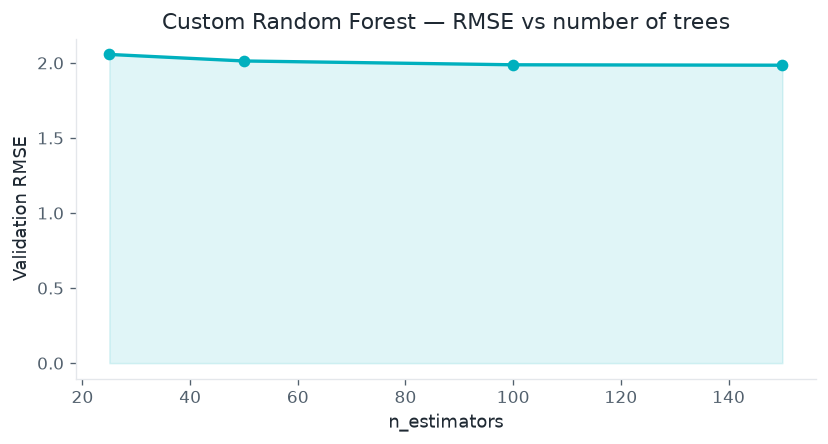

In [6]:
rf_grid = {
    "n_estimators": [25, 50, 100, 150],
    "max_samples": [100, 200, 400, 800],
    "max_depth": [5, 7, 9, 11, 15],
}
rf_combos = list(ParameterGrid(rf_grid))

rf_val_rmse = []
for params in rf_combos:
    model = CustomRandomForest(**params, random_state=SEED)
    model.fit(X_train_p, y_train)
    rf_val_rmse.append(rmse(y_val, model.predict(X_val_p)))

best_rf_params = rf_combos[int(np.argmin(rf_val_rmse))]
rf_model = CustomRandomForest(**best_rf_params, random_state=SEED).fit(X_train_p, y_train)

print("Best Random Forest params:", best_rf_params)
print(f"Validation RMSE: {rmse(y_val, rf_model.predict(X_val_p)):.4f}")
print(f"Validation MAE:  {mean_absolute_error(y_val, rf_model.predict(X_val_p)):.4f}")

# RMSE vs n_estimators with other best params fixed
n_vals = sorted({p["n_estimators"] for p in rf_combos})
curve = []
for n in n_vals:
    m = CustomRandomForest(**{**best_rf_params, "n_estimators": n}, random_state=SEED)
    m.fit(X_train_p, y_train)
    curve.append(rmse(y_val, m.predict(X_val_p)))

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(n_vals, curve, color=PALETTE["med_blue"], marker="o", linewidth=2)
ax.fill_between(n_vals, curve, alpha=0.12, color=PALETTE["med_blue"])
ax.set_xlabel("n_estimators")
ax.set_ylabel("Validation RMSE")
ax.set_title("Custom Random Forest — RMSE vs number of trees")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_rf_estimators_curve.png", bbox_inches="tight")
plt.show()


## Linear Regression

Ordinary least squares is a simple baseline: it assumes additive linear effects. There are no hyperparameters to tune beyond the preprocessing already applied.


Validation RMSE: 6.0700
Validation MAE:  4.2113


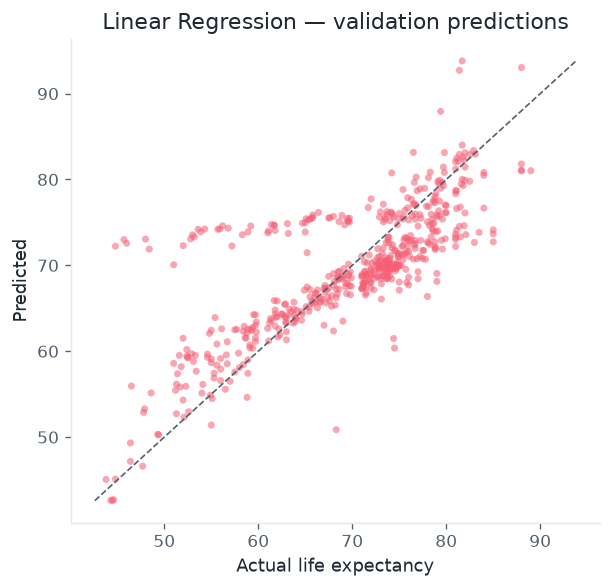

In [7]:
lr_model = LinearRegression().fit(X_train_p, y_train)
lr_val_pred = lr_model.predict(X_val_p)

print(f"Validation RMSE: {rmse(y_val, lr_val_pred):.4f}")
print(f"Validation MAE:  {mean_absolute_error(y_val, lr_val_pred):.4f}")

fig, ax = plt.subplots(figsize=(5.2, 5))
ax.scatter(y_val, lr_val_pred, s=18, alpha=0.55, color=PALETTE["med_pink"], edgecolors="none")
lims = [min(y_val.min(), lr_val_pred.min()), max(y_val.max(), lr_val_pred.max())]
ax.plot(lims, lims, color=PALETTE["slate"], linestyle="--", linewidth=1)
ax.set_xlabel("Actual life expectancy")
ax.set_ylabel("Predicted")
ax.set_title("Linear Regression — validation predictions")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_lr_pred_vs_actual.png", bbox_inches="tight")
plt.show()


## Decision Tree Regressor

A single regression tree can model non-linear interactions but overfits easily. We tune depth, criterion, feature subsampling, and leaf size on validation RMSE.


Best Decision Tree params: {'criterion': 'absolute_error', 'max_depth': 12, 'max_features': 7, 'min_samples_leaf': 5}
Validation RMSE: 2.4049
Validation MAE:  1.6095


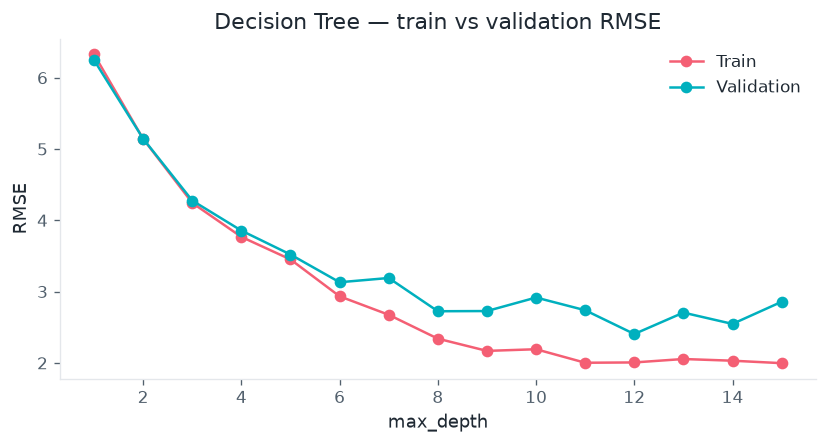

In [8]:
tree_grid = {
    "criterion": ["squared_error", "absolute_error"],
    "max_depth": range(1, 16),
    "max_features": range(1, min(8, X_train_p.shape[1] + 1)),
    "min_samples_leaf": range(1, 21),
}
tree_combos = list(ParameterGrid(tree_grid))

tree_val_rmse, tree_train_rmse = [], []
for params in tree_combos:
    tree = DecisionTreeRegressor(**params, random_state=SEED)
    tree.fit(X_train_p, y_train)
    tree_train_rmse.append(rmse(y_train, tree.predict(X_train_p)))
    tree_val_rmse.append(rmse(y_val, tree.predict(X_val_p)))

best_tree_params = tree_combos[int(np.argmin(tree_val_rmse))]
tree_model = DecisionTreeRegressor(**best_tree_params, random_state=SEED).fit(X_train_p, y_train)

print("Best Decision Tree params:", best_tree_params)
print(f"Validation RMSE: {rmse(y_val, tree_model.predict(X_val_p)):.4f}")
print(f"Validation MAE:  {mean_absolute_error(y_val, tree_model.predict(X_val_p)):.4f}")

depths = sorted(set(p["max_depth"] for p in tree_combos))
val_by_depth, train_by_depth = [], []
for d in depths:
    params = {**best_tree_params, "max_depth": d}
    m = DecisionTreeRegressor(**params, random_state=SEED).fit(X_train_p, y_train)
    train_by_depth.append(rmse(y_train, m.predict(X_train_p)))
    val_by_depth.append(rmse(y_val, m.predict(X_val_p)))

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(depths, train_by_depth, color=PALETTE["med_pink"], marker="o", label="Train")
ax.plot(depths, val_by_depth, color=PALETTE["med_blue"], marker="o", label="Validation")
ax.set_xlabel("max_depth")
ax.set_ylabel("RMSE")
ax.set_title("Decision Tree — train vs validation RMSE")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_tree_depth_curve.png", bbox_inches="tight")
plt.show()


## Model comparison and final evaluation

We select the model with the lowest **validation RMSE**, then report once on the held-out test set.


,val_rmse,val_mae
model,,
Random Forest,1.9846,1.3438
Linear Regression,6.0700,4.2113
Decision Tree,2.4049,1.6095


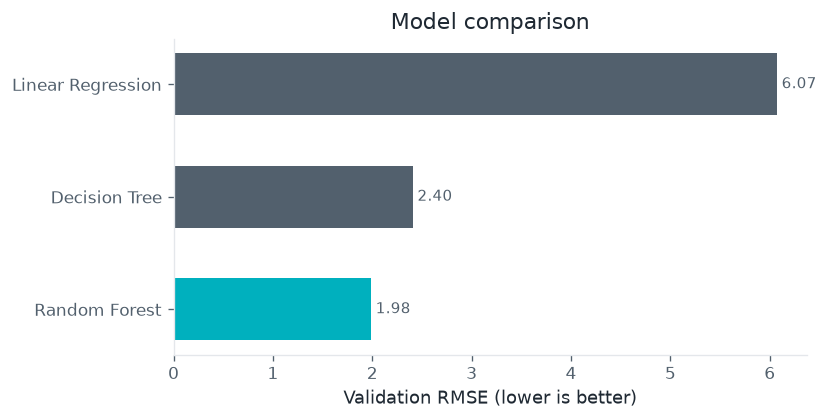

Selected model: Random Forest
Held-out test RMSE: 1.7500
Held-out test MAE:  1.2301


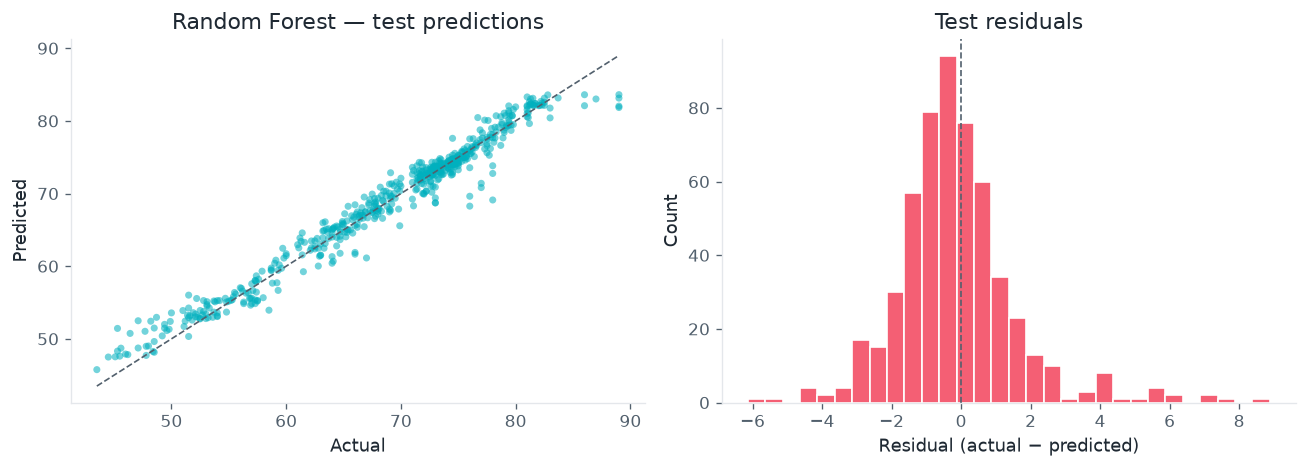

In [9]:
metrics = pd.DataFrame(
    {
        "model": ["Random Forest", "Linear Regression", "Decision Tree"],
        "val_rmse": [
            rmse(y_val, rf_model.predict(X_val_p)),
            rmse(y_val, lr_model.predict(X_val_p)),
            rmse(y_val, tree_model.predict(X_val_p)),
        ],
        "val_mae": [
            mean_absolute_error(y_val, rf_model.predict(X_val_p)),
            mean_absolute_error(y_val, lr_model.predict(X_val_p)),
            mean_absolute_error(y_val, tree_model.predict(X_val_p)),
        ],
    }
).set_index("model")

display(metrics.round(4))

order = metrics["val_rmse"].sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 3.6))
colors = [
    PALETTE["med_blue"] if m == order.index[0] else PALETTE["slate"] for m in order.index
]
ax.barh(order.index, order.values, color=colors, height=0.55)
ax.set_xlabel("Validation RMSE (lower is better)")
ax.set_title("Model comparison")
for i, (name, val) in enumerate(order.items()):
    ax.text(val + 0.05, i, f"{val:.2f}", va="center", color=PALETTE["slate"], fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_model_comparison.png", bbox_inches="tight")
plt.show()

best_name = order.index[0]
final_model = {
    "Random Forest": rf_model,
    "Linear Regression": lr_model,
    "Decision Tree": tree_model,
}[best_name]

y_test_pred = final_model.predict(X_test_p)
print(f"Selected model: {best_name}")
print(f"Held-out test RMSE: {rmse(y_test, y_test_pred):.4f}")
print(f"Held-out test MAE:  {mean_absolute_error(y_test, y_test_pred):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_test, y_test_pred, s=18, alpha=0.55, color=PALETTE["med_blue"], edgecolors="none")
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
axes[0].plot(lims, lims, color=PALETTE["slate"], linestyle="--", linewidth=1)
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].set_title(f"{best_name} — test predictions")

residuals = y_test.to_numpy() - y_test_pred
axes[1].hist(residuals, bins=30, color=PALETTE["med_pink"], edgecolor="white")
axes[1].axvline(0, color=PALETTE["slate"], linestyle="--", linewidth=1)
axes[1].set_xlabel("Residual (actual − predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title("Test residuals")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "07_final_test_diagnostics.png", bbox_inches="tight")
plt.show()


## Takeaways

1. Health and socio-economic predictors of life expectancy interact in ways a **linear model** often underfits.
2. A **from-scratch Random Forest** (bootstrap aggregation of regression trees) is a strong non-linear baseline and usually leads the comparison on validation RMSE.
3. Dropping collinear and high-cardinality fields keeps the feature space manageable without complex encoding.
4. Expected error on new data is summarized by the held-out **test RMSE / MAE** for the selected model.
